<a href="https://colab.research.google.com/github/vaishnavidangi704-commits/CSL701-11_Machine-Learning-Lab/blob/main/Experiments%20and%20Mini-Project/EXP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Vaishnavi Suryakant Dangi

Roll no: CS-11

**Aim:** To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.

**Objectives**

* Understand SLR  
* Load/preprocess dataset
* Perform EDA
* Compute OLS coefficients
* Evaluate with SSE, MSE, R²
* Visualize regression and residual plots










**Software Requirements**


* Python 3.x
* Jupyter/Colab/VS Code
* Libraries: pandas, numpy,matplotlib, seaborn






**Theory**

Linear regression models the relationship between a target continuous variable Y and an input feature vector X using a linear equation:

yˆ=w0+w1x1


In matrix form, including the bias/intercept term X0=1:

yˆ=Xw



To find the optimal weight vector wˆ, the Ordinary Least Squares (OLS) method minimizes the Sum of Squared Errors (SSE) between actual target values y and predicted values yˆ:



SSE=i=1Nyi-yˆi2=y-XwTy-Xw



Solving for w analytically yields the normal equation:

wˆ=XTX-1XTy



Note: The inverse XTX-1 exists only if the matrix XTX is non-singular (i.e., its determinant is non-zero).








**Algorithm**


1.Import libraries

2.Load Auto MPG dataset

3.Inspect and clean data

4.Select horsepower and mpg

5.Plot scatter graph

6.Add bias term

7.Compute correlation

8.Calculate OLS weights

9.Predict values

10.Compute residuals

11.Calculate SSE, MSE, R²

12.Plot regression and residual graphs

13.Interpret results.

14.Upload the google colab onto Git hub repository.















                             Source Code & Output

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("auto-mpg.csv")

In [4]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [6]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [7]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [8]:
df['horsepower'] = df['horsepower'].replace('?', np.nan)

In [9]:
df['horsepower'] = pd.to_numeric(df['horsepower'])

In [10]:
df = df.dropna()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 30.6+ KB


In [12]:
X = df['horsepower'].values

In [13]:
y = df['mpg'].values

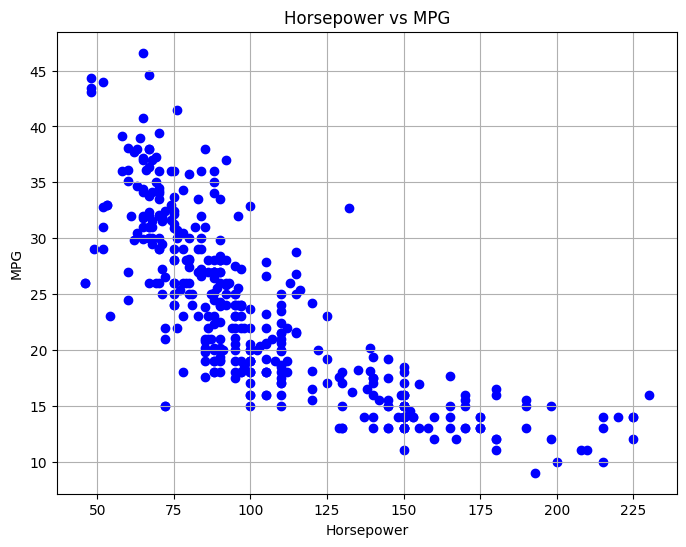

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(X, y, color='blue')
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.grid(True)
plt.show()

In [15]:
X_bias = np.c_[np.ones(len(X)), X]

In [16]:
X_bias[:5]

array([[  1., 130.],
       [  1., 165.],
       [  1., 150.],
       [  1., 150.],
       [  1., 140.]])

In [17]:
correlation = np.corrcoef(X, y)[0,1]
print("Correlation:", correlation)

Correlation: -0.7784267838977756


In [19]:
weights = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y

In [20]:
print("Intercept:", weights[0])
print("Slope:", weights[1])

Intercept: 39.9358610211705
Slope: -0.15784473335365387


In [21]:
y_pred = X_bias @ weights

In [22]:
print(y_pred[:10])

[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


In [23]:
residuals = y - y_pred

In [24]:
print(residuals[:10])

[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


In [25]:
SSE = np.sum(residuals**2)
print("SSE =", SSE)

SSE = 9385.915871932419


In [26]:
MSE = SSE / len(y)
print("MSE =", MSE)

MSE = 23.943662938603108


In [27]:
SST = np.sum((y - np.mean(y))**2)

R2 = 1 - (SSE / SST)

print("R² =", R2)

R² = 0.6059482578894348


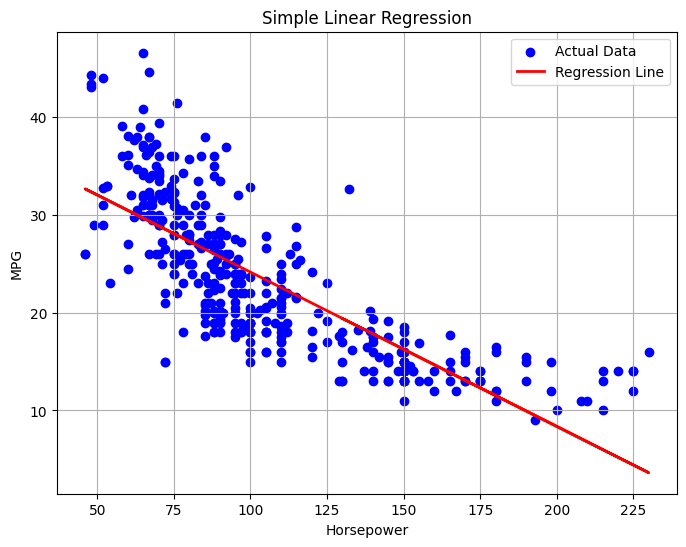

In [30]:
plt.figure(figsize=(8,6))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Simple Linear Regression")
plt.grid(True)
plt.legend()
plt.show()

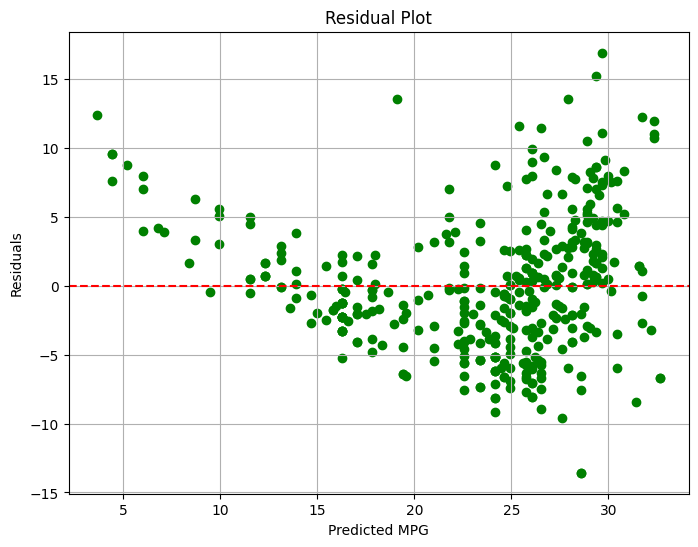

In [31]:
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

**Conclusion**

The experiment successfully implemented Simple Linear Regression using OLS. Horsepower showed a negative relationship with MPG, and evaluation metrics demonstrated reasonable predictive performance.
